In [14]:
# GLOBAL INFLATION ANALYSIS POST COVID

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
# ==============================
# 1. Introduction
# Dikerjakan oleh: Gesang Amukti
# ==============================

In [17]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


In [18]:
# ==============================
# 2. Load Data
# Dikerjakan oleh: Gesang Amukti
# ==============================

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/drive/MyDrive/2TI4_data-science/GlobalInflationAnalysisPost-COVID(EDA & Insight)/global_inflation_post_covid.csv")

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   country             100000 non-null  object 
 1   date                100000 non-null  object 
 2   inflation_rate      100000 non-null  float64
 3   interest_rate       100000 non-null  float64
 4   oil_price           100000 non-null  float64
 5   gdp_growth          100000 non-null  float64
 6   unemployment_rate   100000 non-null  float64
 7   money_supply_m2     100000 non-null  float64
 8   exchange_rate_usd   100000 non-null  float64
 9   food_price_index    100000 non-null  float64
 10  supply_chain_index  100000 non-null  float64
dtypes: float64(9), object(2)
memory usage: 8.4+ MB


In [20]:
# ==============================
# 3. Data Cleaning
# Dikerjakan oleh: Gesang Amukti
# ==============================

In [21]:
df['date'] = pd.to_datetime(df['date'])

df.isnull().sum()

df.describe()

,date,inflation_rate,interest_rate,oil_price,gdp_growth,unemployment_rate,money_supply_m2,exchange_rate_usd,food_price_index,supply_chain_index
count,100000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,2022-06-17 22:14:00.095999744,4.175859,2.559960,75.026843,2.476658,5.514667,11947.973270,46.908610,119.597836,1.939958
min,2020-01-01 00:00:00,-1.999003,-2.810000,22.640000,-4.580000,2.000000,3858.000000,2.340000,70.770000,1.000000
25%,2021-03-01 00:00:00,3.173408,1.190000,62.860000,1.090000,4.710000,10060.000000,22.610000,107.180000,1.240000
50%,2022-07-01 00:00:00,4.226506,2.590000,75.200000,2.520000,5.500000,11788.000000,42.360000,119.830000,1.670000
75%,2023-10-01 00:00:00,5.202572,3.940000,85.680000,3.940000,6.340000,13690.000000,73.310000,132.420000,2.270000
max,2024-12-01 00:00:00,9.634656,8.130000,153.770000,10.090000,9.140000,21241.000000,104.950000,165.300000,4.880000
std,NaN,1.463516,1.856475,24.380590,2.156974,1.199608,2744.008662,30.259072,17.118195,0.912450


In [22]:
# ==============================
# 4. Inflation Ditribution
# Dikerjakan oleh: Abdillah Muhklis
# ==============================

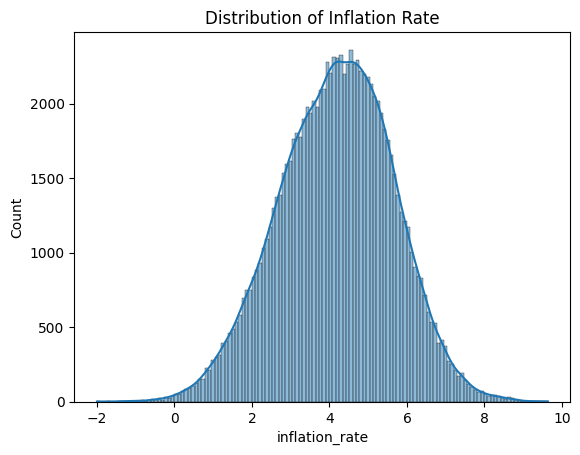

In [23]:
plt.figure()
sns.histplot(df['inflation_rate'], kde=True)
plt.title("Distribution of Inflation Rate")
plt.show()

In [24]:
# ==============================
# 5. Inflation by Country
# Dikerjakan oleh: Abdillah Muhklis
# ==============================

In [25]:
df_plot = df.groupby(['country', 'date'], as_index=False)['inflation_rate'].mean()

top_countries = df_plot['country'].value_counts().index[:5]

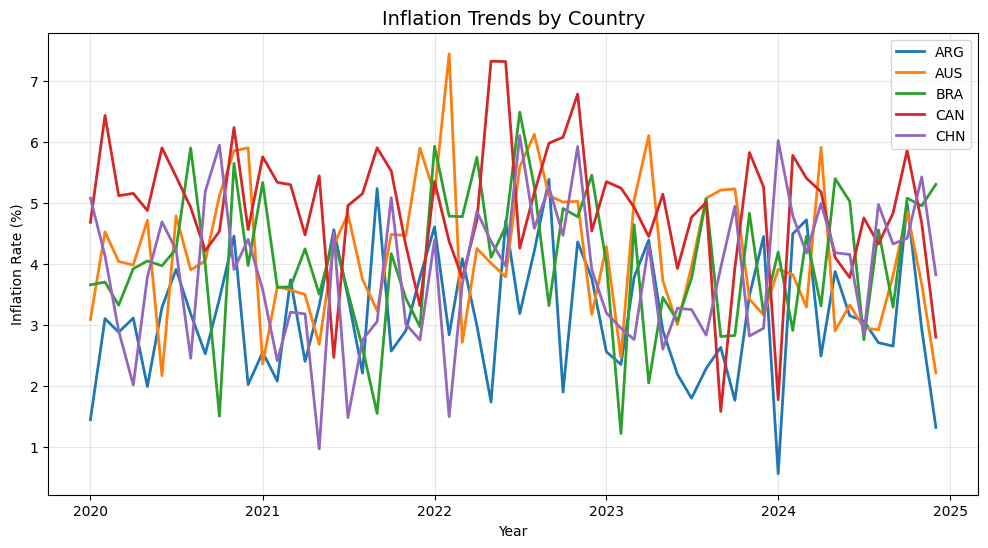

In [26]:
plt.figure(figsize=(12,6))

for c in top_countries:
    temp = df_plot[df_plot['country'] == c]
    plt.plot(temp['date'], temp['inflation_rate'], linewidth=2)

plt.title("Inflation Trends by Country", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Inflation Rate (%)")
plt.legend(top_countries)
plt.grid(True, alpha=0.3)

plt.show()

In [27]:
# ==============================
# 6. Oil Price vs Inflation
# Dikerjakan oleh: Ayu Chandra Al Mega
# ==============================

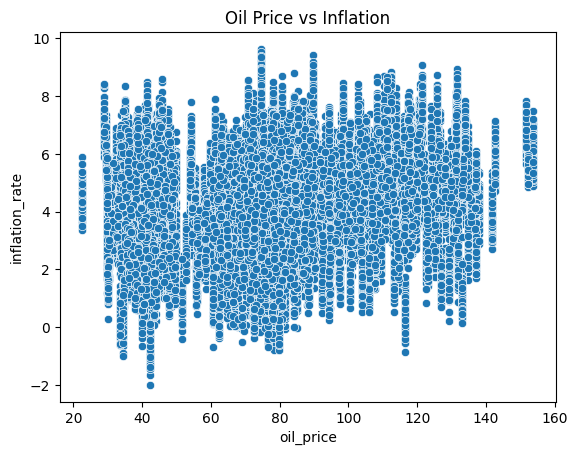

In [28]:
plt.figure()
sns.scatterplot(x='oil_price', y='inflation_rate', data=df)
plt.title("Oil Price vs Inflation")
plt.show()

In [29]:
# ==============================
# 7. Correlation Heatmap
# Dikerjakan oleh: Ayu Chandra Al Mega
# ==============================

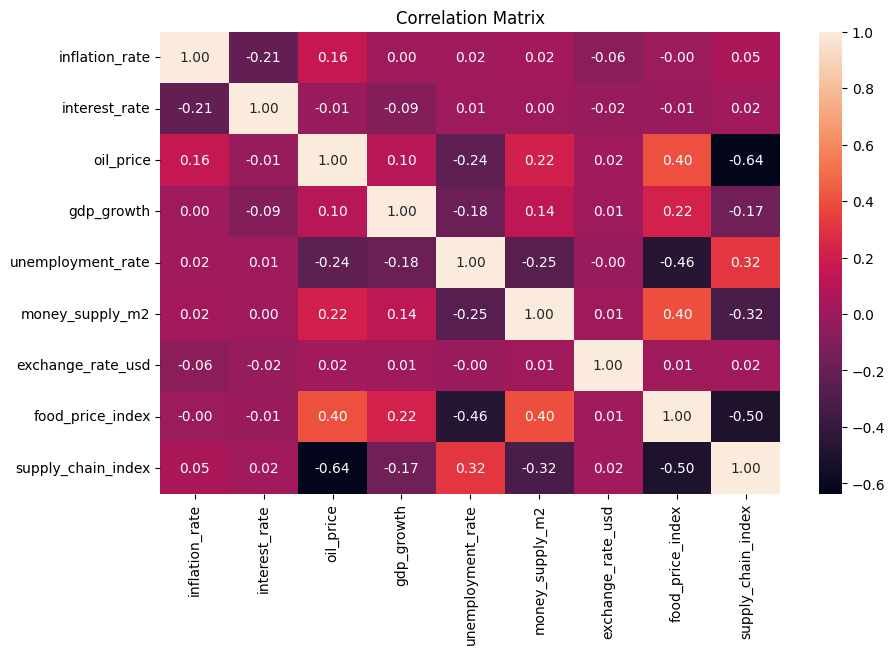

In [30]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f")
plt.title("Correlation Matrix")
plt.show()